In [8]:
#1
!pip install gensim scipy
#2
import gensim.downloader as api
from scipy.spatial.distance import cosine
#3
print("loading word2vec")
model=api.load("word2vec-google-news-300")
print("model loaded successfully")

#4
vector=model['king']
print("the 10 dimensions of vector king is:")
print(vector[:10] ,"\n")

#5
print("similar word for king:")
for word,similarity in model.most_similar('king'):
    print(f"{word}:{similarity:.4f}")
print()

#6 king -man+woman =queen
print("analogy1")
result=model.most_similar(positive=["king","woman"],negative=["man"],topn=1)
print(f"Result:{result[0][0]} ,(similarity:{result[0][1]:.4f}")

#7 paris+itlay-france =rome
print("analogy2")
for word,similarity in model.most_similar(positive=["paris","italy",],negative=["france"]):
    print(f"{word}:{similarity:.4f}")
print()
#8 walking+swimming-walk=swim
print("analogy3")
for word,similarity in model.most_similar(positive=["walking","swimming",],negative=["walk"]):
    print(f"{word}:{similarity:.4f}")
print()
#9 cosine similarity
similarity=1-cosine(model['king'],model['queen'])
print(f"cosine similarity is {similarity}")










loading word2vec
model loaded successfully
the 10 dimensions of vector king is:
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125] 

similar word for king:
kings:0.7138
queen:0.6511
monarch:0.6413
crown_prince:0.6204
prince:0.6160
sultan:0.5865
ruler:0.5798
princes:0.5647
Prince_Paras:0.5433
throne:0.5422

analogy1
Result:queen ,(similarity:0.7118
analogy2
lohan:0.5070
madrid:0.4818
heidi:0.4800
real_madrid:0.4753
florence:0.4682
diego:0.4673
ronnie:0.4672
juventus:0.4672
joel:0.4654
huntelaar:0.4636

analogy3
Swimming:0.6006
swim:0.5949
swimmers:0.5835
swimmer:0.5819
paddling:0.5744
kayaking:0.5662
swam:0.5506
rowing:0.5436
swims:0.5371
canoeing:0.5140

cosine similarity is 0.6510956883430481


computers:0.80
laptop:0.66
laptop_computer:0.65
Computer:0.65
com_puter:0.61


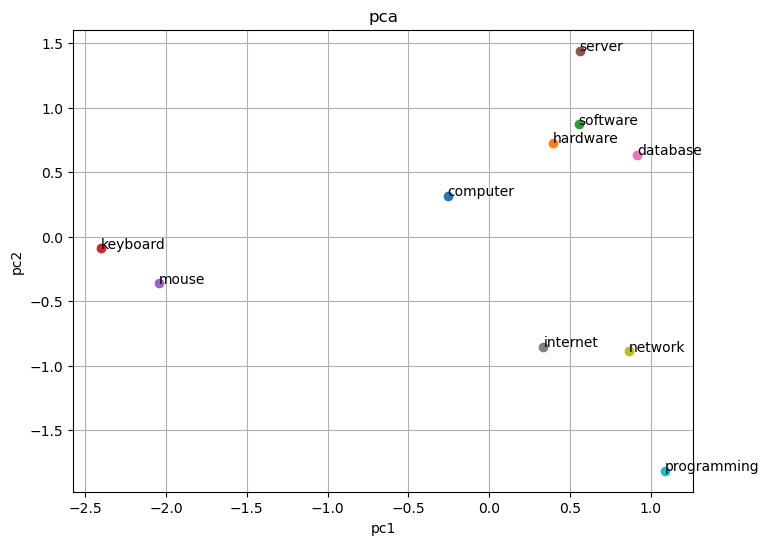

In [12]:
#pgm 2
#1 
!pip install gensim matplotlib scikit-learn
#2
import gensim.downloader as api
import matplotlib.pyplot  as plt
from sklearn.decomposition import PCA
#3
model=api.load("word2vec-google-news-300")

#4 take input
words=['computer','hardware','software','keyboard','mouse','server','database','internet','network','programming']
vector=[model[word] for word in words]

#5 pca
pca=PCA(n_components=2)
reduced=pca.fit_transform(vector)

#6 computer similar words
input_word='computer'
similar_word=model.most_similar(input_word,topn=5)
for word,similarity in similar_word:
    print(f"{word}:{similarity:.2f}")
#7 plot
plt.figure(figsize=(8,6))
for i,word in enumerate(words):
    plt.scatter(reduced[i,0],reduced[i,1])
    plt.annotate(word,(reduced[i,0],reduced[i,1]))
plt.title("pca")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.grid(True)
plt.show()



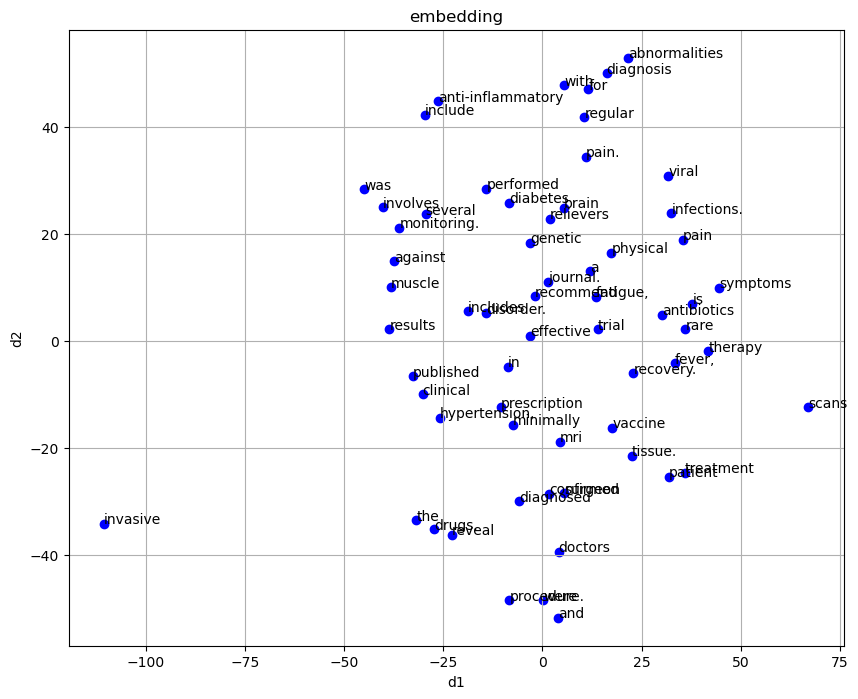

words similar to treatment
patient:0.2556
pain.:0.1441
brain:0.1151
muscle:0.1138
against:0.1115
words similar to vaccine
disorder.:0.1931
tissue.:0.1388
recovery.:0.1172
therapy:0.0974
doctors:0.0907


In [16]:
#pgm3 
#1
!pip install gensim matplotlib scikit-learn
#2
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

#3
medical_corpus=[
 "patient was diagnosed with diabetes and hypertension.",
 "MRI scans reveal abnormalities in the brain tissue.",
 "The treatment involves antibiotics and regular monitoring.",
 "Symptoms include fever, fatigue, and muscle pain.",
 "The vaccine is effective against several viral infections.",
 "Doctors recommend physical therapy for recovery.",
 "The clinical trial results were published in the journal.",
 "The surgeon performed a minimally invasive procedure.",
 "The prescription includes pain relievers and anti-inflammatory drugs.",
 "The diagnosis confirmed a rare genetic disorder."
]
#4 tokenize and lowercase
preprocessed_corpus=[ sentence.lower().split() for sentence in medical_corpus]

#5 
model=Word2Vec(sentences=preprocessed_corpus,vector_size=100,epochs=50,workers=4,min_count=1,window=5)
#6 embeddings
words=list(model.wv.index_to_key)
embedding=np.array([model.wv[word] for word in words])
#7tsne
tsne=TSNE(n_components=2,random_state=42,perplexity=5)
tsne_result=tsne.fit_transform(embedding)
#8
plt.figure(figsize=(10,8))
plt.scatter(tsne_result[:,0],tsne_result[:,1],color='blue')
for i,word in enumerate(words):
    plt.text(tsne_result[i,0]+0.02,tsne_result[i,1]+0.02,word)
plt.title("embedding")
plt.xlabel("d1")
plt.ylabel("d2")
plt.grid(True)
plt.show()

#9
def find_similar_words(input_words,top_n=5):
    try:
        similar_words=model.wv.most_similar(input_words,topn=top_n)
        print(f"words similar to {input_words}")
        for word ,similar in similar_words:
            print(f"{word}:{similar:.4f}")
    except KeyError:
        print(f"{input_words} not in voca")
find_similar_words("treatment")
find_similar_words("vaccine")



